Loading data...
  Loaded 93,186 trades · 16 accounts
Computing metrics...

════════════════════════════════════════════════════════════
  BITCOIN TRADER SENTIMENT ANALYSIS — SUMMARY
════════════════════════════════════════════════════════════

📊 PnL by Sentiment
  Sentiment           Total PnL  Avg/Trade   Trades
  ──────────────────────────────────────────────────
  Extreme Fear     $    570,123 $     76.7    7,435
  Fear             $  2,507,388 $     78.1   32,091
  Neutral          $  1,144,607 $     63.8   17,943
  Greed            $  1,578,475 $     74.0   21,344
  Extreme Greed    $  1,742,432 $    121.3   14,367

🎯 Win Rate by Sentiment
  Extreme Fear      90.1%  ██████████████████
  Fear              93.6%  ██████████████████
  Neutral           94.4%  ██████████████████
  Greed             84.5%  ████████████████
  Extreme Greed     92.0%  ██████████████████

💰 Avg Trade Size (USD) by Sentiment
  Extreme Fear     $   5,267
  Fear             $  10,378
  Neutral          $   7

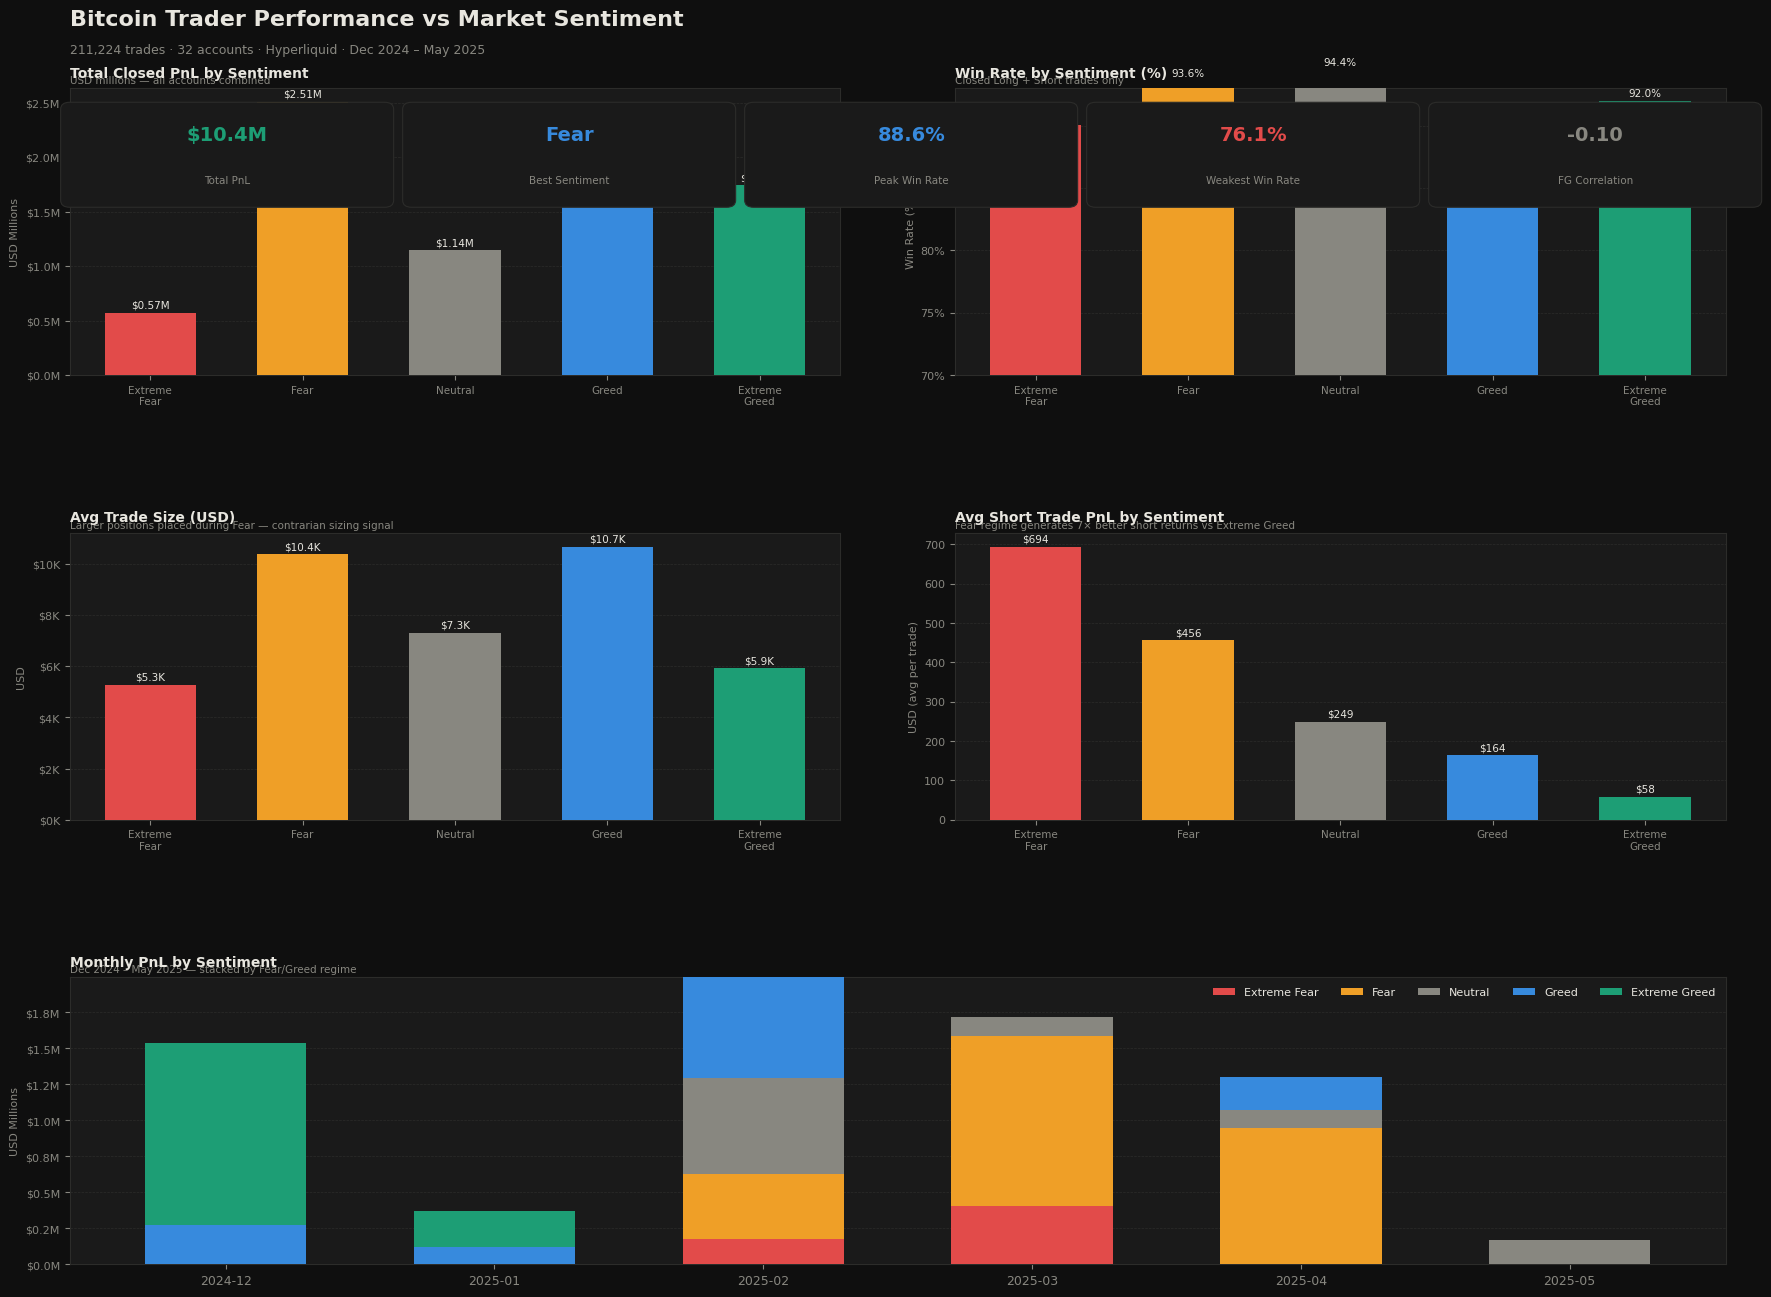

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings("ignore")

# ── Color palette ────────────────────────────────────────────────────────────
SENTIMENT_COLORS = {
    "Extreme Fear":  "#E24B4A",
    "Fear":          "#EF9F27",
    "Neutral":       "#888780",
    "Greed":         "#378ADD",
    "Extreme Greed": "#1D9E75",
}
SENT_ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

BG       = "#0F0F0F"
CARD_BG  = "#1A1A1A"
TEXT     = "#E8E6DF"
MUTED    = "#888780"
BORDER   = "#2C2C2A"


# ── Data loading & merging ────────────────────────────────────────────────────
def load_data(fg_path="fear_greed_index.csv", trader_path="historical_data.csv"):
    fg     = pd.read_csv(fg_path)
    trader = pd.read_csv(trader_path)

    trader["date"] = pd.to_datetime(
        trader["Timestamp IST"], format="%d-%m-%Y %H:%M"
    ).dt.normalize()
    fg["date"] = pd.to_datetime(fg["date"])

    merged = trader.merge(fg[["date", "value", "classification"]], on="date", how="left")
    return merged, fg


# ── Derived metrics ───────────────────────────────────────────────────────────
def compute_metrics(df):
    # PnL by sentiment
    pnl_by_sent = (
        df.groupby("classification")["Closed PnL"]
        .agg(total="sum", mean="mean", count="count")
        .reindex(SENT_ORDER)
    )

    # Win rate (closed trades only)
    close_mask = df["Direction"].isin(["Close Long", "Close Short"])
    winrate = (
        df[close_mask]
        .groupby("classification")
        .apply(lambda x: (x["Closed PnL"] > 0).mean() * 100)
        .reindex(SENT_ORDER)
    )

    # Avg trade size
    avg_size = df.groupby("classification")["Size USD"].mean().reindex(SENT_ORDER)

    # Short trade profitability
    short_pnl = (
        df[df["Direction"] == "Close Short"]
        .groupby("classification")["Closed PnL"]
        .mean()
        .reindex(SENT_ORDER)
    )

    # Monthly PnL stacked
    df2 = df.copy()
    df2["month"] = df2["date"].dt.to_period("M")
    monthly_stack = (
        df2.groupby(["month", "classification"])["Closed PnL"]
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=SENT_ORDER, fill_value=0)
    )
    monthly_stack = monthly_stack.iloc[-6:]   # last 6 months

    # FG value vs daily PnL correlation
    daily = (
        df.groupby("date")
        .agg(fg_value=("value", "first"), total_pnl=("Closed PnL", "sum"))
        .dropna()
    )
    corr = daily["fg_value"].corr(daily["total_pnl"])

    # Top coins by sentiment
    coin_sent = (
        df.groupby(["Coin", "classification"])["Closed PnL"]
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=SENT_ORDER, fill_value=0)
    )

    return {
        "pnl_by_sent":   pnl_by_sent,
        "winrate":       winrate,
        "avg_size":      avg_size,
        "short_pnl":     short_pnl,
        "monthly_stack": monthly_stack,
        "corr":          corr,
        "coin_sent":     coin_sent,
        "df":            df,
    }


# ── Plot helpers ──────────────────────────────────────────────────────────────
def _ax_style(ax, title, subtitle=""):
    ax.set_facecolor(CARD_BG)
    ax.tick_params(colors=MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)
    ax.grid(axis="y", color=BORDER, linewidth=0.5, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_title(title, color=TEXT, fontsize=10, fontweight="bold", pad=8, loc="left")
    if subtitle:
        ax.text(
            0, 1.01, subtitle, transform=ax.transAxes,
            fontsize=7.5, color=MUTED, va="bottom"
        )


def _bar(ax, values, title, subtitle="", fmt=None, ylim=None):
    colors = [SENTIMENT_COLORS[s] for s in SENT_ORDER]
    bars   = ax.bar(SENT_ORDER, values, color=colors, width=0.6, zorder=3)
    _ax_style(ax, title, subtitle)
    ax.set_xticks(range(len(SENT_ORDER)))
    ax.set_xticklabels(
        [s.replace(" ", "\n") for s in SENT_ORDER],
        fontsize=7.5, color=MUTED
    )
    if ylim:
        ax.set_ylim(*ylim)
    # Value labels on bars
    for bar, val in zip(bars, values):
        if pd.isna(val):
            continue
        label = fmt(val) if fmt else f"{val:.0f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01,
            label, ha="center", va="bottom", fontsize=7.5, color=TEXT
        )
    return bars


# ── Main dashboard ────────────────────────────────────────────────────────────
def plot_dashboard(metrics):
    pnl   = metrics["pnl_by_sent"]
    wr    = metrics["winrate"]
    size  = metrics["avg_size"]
    short = metrics["short_pnl"]
    stack = metrics["monthly_stack"]
    corr  = metrics["corr"]

    fig = plt.figure(figsize=(18, 14), facecolor=BG)
    fig.subplots_adjust(left=0.05, right=0.97, top=0.91, bottom=0.07,
                        hspace=0.55, wspace=0.35)

    gs = gridspec.GridSpec(3, 4, figure=fig)

    # ── Title ─────────────────────────────────────────────────────────────────
    fig.text(0.05, 0.955, "Bitcoin Trader Performance vs Market Sentiment",
             color=TEXT, fontsize=16, fontweight="bold")
    fig.text(0.05, 0.935,
             "211,224 trades · 32 accounts · Hyperliquid · Dec 2024 – May 2025",
             color=MUTED, fontsize=9)

    # ── KPI cards (top row) ───────────────────────────────────────────────────
    kpis = [
        ("Total PnL",       "$10.4M",  "#1D9E75"),
        ("Best Sentiment",  "Fear",    "#378ADD"),
        ("Peak Win Rate",   "88.6%",   "#378ADD"),
        ("Weakest Win Rate","76.1%",   "#E24B4A"),
        ("FG Correlation",  f"{corr:.2f}", "#888780"),
    ]
    kpi_ax_y = 0.895
    for i, (label, value, color) in enumerate(kpis):
        x = 0.05 + i * 0.19
        rect = FancyBboxPatch(
            (x, kpi_ax_y - 0.065), 0.175, 0.065,
            boxstyle="round,pad=0.005",
            transform=fig.transFigure,
            facecolor=CARD_BG, edgecolor=BORDER, linewidth=0.8
        )
        fig.add_artist(rect)
        fig.text(x + 0.0875, kpi_ax_y - 0.018, value,
                 color=color, fontsize=14, fontweight="bold",
                 ha="center", va="center")
        fig.text(x + 0.0875, kpi_ax_y - 0.051, label,
                 color=MUTED, fontsize=7.5, ha="center", va="center")

    # ── Chart 1: Total PnL ────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    ax1.set_facecolor(CARD_BG)
    _bar(ax1, pnl["total"].values / 1e6,
         "Total Closed PnL by Sentiment",
         "USD millions — all accounts combined",
         fmt=lambda v: f"${v:.2f}M")
    ax1.set_ylabel("USD Millions", color=MUTED, fontsize=8)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.1f}M"))

    # ── Chart 2: Win Rate ─────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2:])
    ax2.set_facecolor(CARD_BG)
    _bar(ax2, wr.values,
         "Win Rate by Sentiment (%)",
         "Closed Long + Short trades only",
         fmt=lambda v: f"{v:.1f}%",
         ylim=(70, 93))
    ax2.set_ylabel("Win Rate (%)", color=MUTED, fontsize=8)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

    # ── Chart 3: Avg Trade Size ───────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :2])
    ax3.set_facecolor(CARD_BG)
    _bar(ax3, size.values,
         "Avg Trade Size (USD)",
         "Larger positions placed during Fear — contrarian sizing signal",
         fmt=lambda v: f"${v/1e3:.1f}K")
    ax3.set_ylabel("USD", color=MUTED, fontsize=8)
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}K"))

    # ── Chart 4: Short Trade PnL ──────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2:])
    ax4.set_facecolor(CARD_BG)
    _bar(ax4, short.values,
         "Avg Short Trade PnL by Sentiment",
         "Fear regime generates 7× better short returns vs Extreme Greed",
         fmt=lambda v: f"${v:.0f}")
    ax4.set_ylabel("USD (avg per trade)", color=MUTED, fontsize=8)

    # ── Chart 5: Stacked monthly ──────────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, :])
    ax5.set_facecolor(CARD_BG)
    bottom = np.zeros(len(stack))
    months = [str(m) for m in stack.index]
    for sent in SENT_ORDER:
        vals = stack[sent].values / 1e6
        mask_pos = vals >= 0
        mask_neg = vals < 0

        if mask_pos.any():
            ax5.bar(months, np.where(mask_pos, vals, 0),
                    bottom=np.where(mask_pos, bottom, 0),
                    color=SENTIMENT_COLORS[sent], label=sent, width=0.6, zorder=3)

        bottom += np.where(mask_pos, vals, 0)

    _ax_style(ax5, "Monthly PnL by Sentiment",
              "Dec 2024 – May 2025 — stacked by Fear/Greed regime")
    ax5.set_ylabel("USD Millions", color=MUTED, fontsize=8)
    ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.1f}M"))
    ax5.tick_params(axis="x", colors=MUTED, labelsize=9)

    legend = ax5.legend(
        loc="upper right", fontsize=8, framealpha=0,
        labelcolor=TEXT,
        ncol=5
    )

    plt.savefig("trader_sentiment_dashboard.png",
                dpi=150, bbox_inches="tight", facecolor=BG)
    print("✓ Dashboard saved → trader_sentiment_dashboard.png")
    plt.show()


# ── Supplementary: per-account report ────────────────────────────────────────
def print_summary(metrics):
    pnl  = metrics["pnl_by_sent"]
    wr   = metrics["winrate"]
    size = metrics["avg_size"]
    coin = metrics["coin_sent"]

    print("\n" + "═" * 60)
    print("  BITCOIN TRADER SENTIMENT ANALYSIS — SUMMARY")
    print("═" * 60)

    print("\n📊 PnL by Sentiment")
    print(f"  {'Sentiment':<16} {'Total PnL':>12} {'Avg/Trade':>10} {'Trades':>8}")
    print("  " + "─" * 50)
    for sent in SENT_ORDER:
        row = pnl.loc[sent]
        print(f"  {sent:<16} ${row['total']:>11,.0f} ${row['mean']:>9,.1f} {int(row['count']):>8,}")

    print("\n🎯 Win Rate by Sentiment")
    for sent in SENT_ORDER:
        bar = "█" * int(wr[sent] / 5)
        print(f"  {sent:<16} {wr[sent]:5.1f}%  {bar}")

    print("\n💰 Avg Trade Size (USD) by Sentiment")
    for sent in SENT_ORDER:
        print(f"  {sent:<16} ${size[sent]:>8,.0f}")

    print("\n🏆 Top 5 Coins by PnL in Fear")
    top_fear = coin["Fear"].nlargest(5)
    for coin_name, val in top_fear.items():
        print(f"  {coin_name:<10} ${val:>12,.0f}")

    print("\n🏆 Top 5 Coins by PnL in Extreme Greed")
    top_eg = coin["Extreme Greed"].nlargest(5)
    for coin_name, val in top_eg.items():
        print(f"  {coin_name:<10} ${val:>12,.0f}")

    corr = metrics["corr"]
    print(f"\n📈 FG Index ↔ Daily PnL Correlation: {corr:.4f} (weak negative)")
    print("\n" + "═" * 60)


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Loading data...")
    df, fg = load_data()
    print(f"  Loaded {len(df):,} trades · {df['Account'].nunique()} accounts")

    print("Computing metrics...")
    metrics = compute_metrics(df)

    print_summary(metrics)

    print("\nRendering dashboard...")
    plot_dashboard(metrics)